In [38]:
!pip install tensorflow

In [39]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [40]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset/ML_AI/FruitinAmazon.zip"   # make sure name matches exactly
extract_path = "/content/drive/MyDrive/Dataset/ML_AI"

# Create folder (if not exists)
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete!")

✅ Extraction complete!


In [41]:
import os

print(os.listdir("/content/drive/MyDrive/Dataset/ML_AI"))

['Iris.csv', 'eye.png', 'mnist_dataset.csv', 'ML_Worksheet2.ipynb', 'mnist_3_and_5.csv', 'mnist_0_and_1.csv', 'ML_Workshop3.ipynb', 'Copy of devnagari digit.zip', 'FruitinAmazon.zip', 'FruitinAmazon']


In [42]:
train_dir = "/content/drive/MyDrive/Dataset/ML_AI/"

In [43]:
train_dir = "/content/drive/MyDrive/Dataset/ML_AI/FruitinAmazon/train"

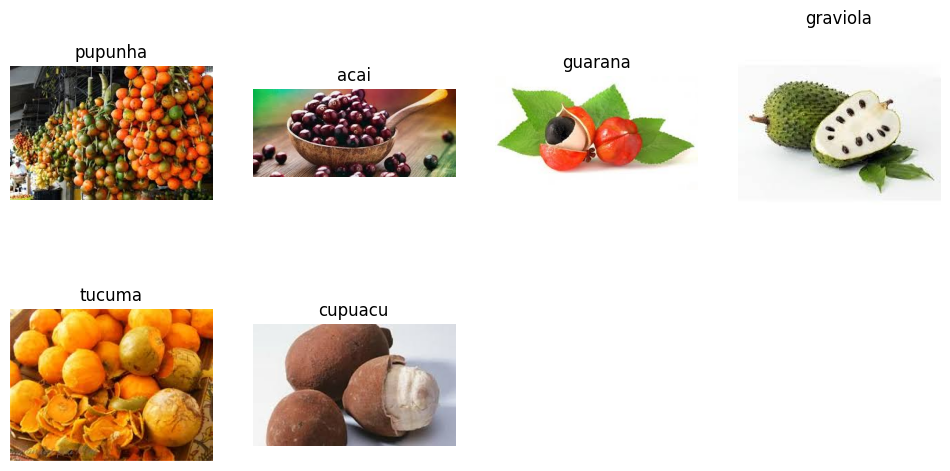

In [44]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

images = []
labels = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    labels.append(cls)

plt.figure(figsize=(12,6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [45]:
from PIL import Image

corrupted = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)

    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)

        try:
            Image.open(img_path).verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed:", img_path)

if len(corrupted) == 0:
    print("No corrupted images found.")

No corrupted images found.


In [46]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [47]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)
early_stop = EarlyStopping(patience=10)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.1748 - loss: 1.9329

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 891ms/step - accuracy: 0.1806 - loss: 1.9830 - val_accuracy: 0.2222 - val_loss: 1.8857
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.3472 - loss: 1.6335 - val_accuracy: 0.2222 - val_loss: 1.8878
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2891 - loss: 1.5308

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.3472 - loss: 1.4543 - val_accuracy: 0.2222 - val_loss: 1.7858
Epoch 4/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3984 - loss: 1.2830 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4861 - loss: 1.2271 - val_accuracy: 0.2222 - val_loss: 1.6662
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6641 - loss: 1.0225 

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.6944 - loss: 1.0220 - val_accuracy: 0.3889 - val_loss: 1.5048
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7778 - loss: 0.7975 - val_accuracy: 0.3333 - val_loss: 1.9649
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7917 - loss: 0.7024 - val_accuracy: 0.3333 - val_loss: 1.7137
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.8750 - loss: 0.5055 - val_accuracy: 0.3889 - val_loss: 1.5051
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8611 - loss: 0.3810 - val_accuracy: 0.1667 - val_loss: 2.0175
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9722 - loss: 0.2159 - val_accuracy: 0.4444 - val_loss: 1.5883
Epoch 11/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9844 - loss: 0.2167 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9722 - loss: 0.2059 - val_accuracy: 0.4444 - val_loss: 1.4472
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.1049 - val_accuracy: 0.3889 - val_loss: 2.0250
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 1.0000 - loss: 0.0694 - val_accuracy: 0.1667 - val_loss: 2.7983
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9861 - loss: 0.0607 - val_accuracy: 0.5000 - val_loss: 1.7537
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 1.0000 - loss: 0.0238 - val_accuracy: 0.5556 - val_loss: 1.6813
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.3889 - val_loss: 2.0684
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.3889 - val_loss: 2.2998
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.3889 - val_lo

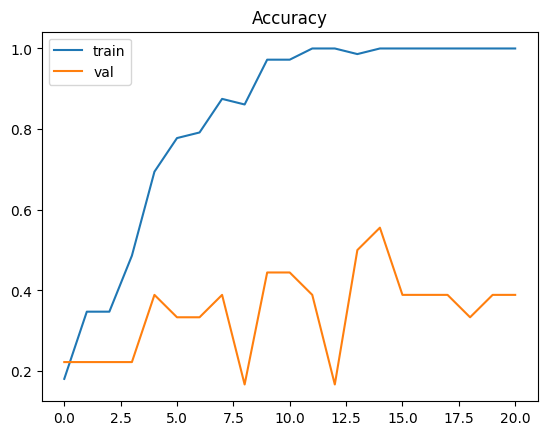

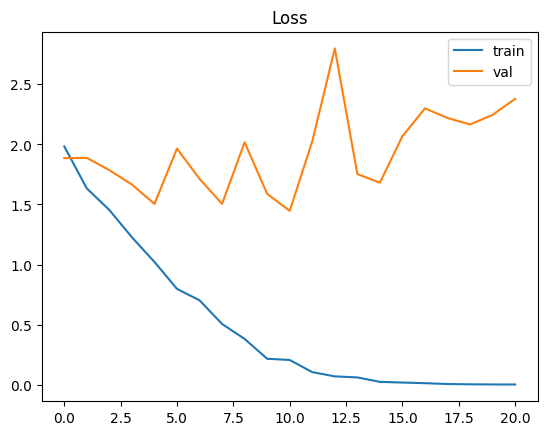

In [50]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [51]:
model.evaluate(val_ds)
model.save("cnn_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3889 - loss: 2.3788


In [52]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
              precision    recall  f1-score   support

     pupunha       0.25      1.00      0.40         1
        acai       0.33      0.50      0.40         2
     guarana       1.00      0.67      0.80         3
    graviola       0.33      0.20      0.25         5
      tucuma       0.00      0.00      0.00         4
     cupuacu       0.50      0.67      0.57         3

    accuracy                           0.39        18
   macro avg       0.40      0.51      0.40        18
weighted avg       0.39      0.39      0.36        18

